In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import numpy.random as npr
import pandas as pd
import time
import seaborn as sns
from datetime import datetime
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from itertools import product

import signature_core as core_cpp
import signature_core_py as core_py
import signature_pricing_cpp as pricing_cpp
import signature_pricing_py as pricing_py
from processes import *

plt.rcParams['figure.dpi'] = 100
generate_new_images = False
np.random.seed(0xDEADBEEF)

# 1 - Shuffle & Tensor Products

In [30]:
# ...

# 2 - European Option Pricing

In [31]:
trunc = 6
call_maturity = 1
bs_vol = 0.20
rho = 1.0
S0 = 120
K = 100

In [37]:
timings = {}

In [44]:
orders = [4, 6, 8]
rk_subdivs = [5, 10, 20]
int_subdivs = [10, 50]

In [48]:
sig_bs = core_cpp.from_numpy([np.array(bs_vol)], 2)
cpp_cache = core_cpp.compute_shuffle_cache(trunc)

for (order, rk_subdvs, int_subdvs) in product(orders, rk_subdivs, int_subdivs):
    print(f"Order: {order}, RK subdivs: {rk_subdvs}, Int subdivs: {int_subdvs}")
    t0 = time.time()
    for _ in range(100):
        _ = pricing_cpp.european_call_sig(S0, call_maturity, K, sig_bs, rho, trunc=trunc, rk_subdivs=rk_subdvs, integral_subdivs=int_subdvs, cache=cpp_cache)
    runtime_cpp = time.time() - t0
    time_per_pricing_cpp = runtime_cpp / 100
    timings[("cpp", order, rk_subdvs, int_subdvs)] = time_per_pricing_cpp

Order: 4, RK subdivs: 5, Int subdivs: 10
Order: 4, RK subdivs: 5, Int subdivs: 50
Order: 4, RK subdivs: 10, Int subdivs: 10
Order: 4, RK subdivs: 10, Int subdivs: 50
Order: 4, RK subdivs: 20, Int subdivs: 10
Order: 4, RK subdivs: 20, Int subdivs: 50
Order: 6, RK subdivs: 5, Int subdivs: 10
Order: 6, RK subdivs: 5, Int subdivs: 50
Order: 6, RK subdivs: 10, Int subdivs: 10
Order: 6, RK subdivs: 10, Int subdivs: 50
Order: 6, RK subdivs: 20, Int subdivs: 10
Order: 6, RK subdivs: 20, Int subdivs: 50
Order: 8, RK subdivs: 5, Int subdivs: 10
Order: 8, RK subdivs: 5, Int subdivs: 50
Order: 8, RK subdivs: 10, Int subdivs: 10
Order: 8, RK subdivs: 10, Int subdivs: 50
Order: 8, RK subdivs: 20, Int subdivs: 10
Order: 8, RK subdivs: 20, Int subdivs: 50


In [49]:
sig_bs = core_py.Sig([np.array(bs_vol)], 2, np.complex128)

for (order, rk_subdvs, int_subdvs) in product(orders, rk_subdivs, int_subdivs):
    print(f"Order: {order}, RK subdivs: {rk_subdvs}, Int subdivs: {int_subdvs}")
    t0 = time.time()
    _ = pricing_py.european_call_sig(S0, call_maturity, K, sig_bs, rho, trunc=trunc, rk_subdivs=rk_subdvs, integral_subdivs=int_subdvs)
    timings[("py", order, rk_subdvs, int_subdvs)] = time.time() - t0

Order: 4, RK subdivs: 5, Int subdivs: 10
Order: 4, RK subdivs: 5, Int subdivs: 50
Order: 4, RK subdivs: 10, Int subdivs: 10
Order: 4, RK subdivs: 10, Int subdivs: 50
Order: 4, RK subdivs: 20, Int subdivs: 10
Order: 4, RK subdivs: 20, Int subdivs: 50
Order: 6, RK subdivs: 5, Int subdivs: 10
Order: 6, RK subdivs: 5, Int subdivs: 50
Order: 6, RK subdivs: 10, Int subdivs: 10
Order: 6, RK subdivs: 10, Int subdivs: 50
Order: 6, RK subdivs: 20, Int subdivs: 10
Order: 6, RK subdivs: 20, Int subdivs: 50
Order: 8, RK subdivs: 5, Int subdivs: 10
Order: 8, RK subdivs: 5, Int subdivs: 50
Order: 8, RK subdivs: 10, Int subdivs: 10
Order: 8, RK subdivs: 10, Int subdivs: 50
Order: 8, RK subdivs: 20, Int subdivs: 10
Order: 8, RK subdivs: 20, Int subdivs: 50


In [ ]:
import json

with open("outputs/performances.json", "w") as f:
    as_list = [ [k for k in key] + [val,] for key, val in timings.items()]
    f.write( json.dumps(as_list) )

with open("outputs/performances.json", "r") as f:
    as_list = json.load(f)
timings = {tuple(item[:-1]): item[-1] for item in as_list}

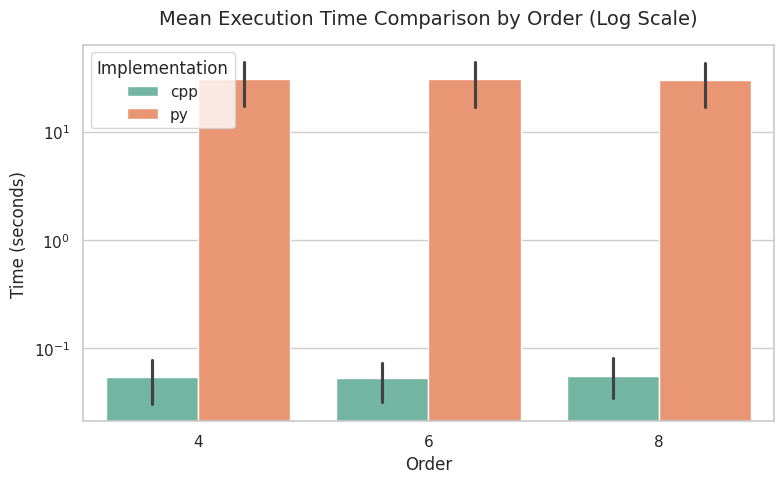

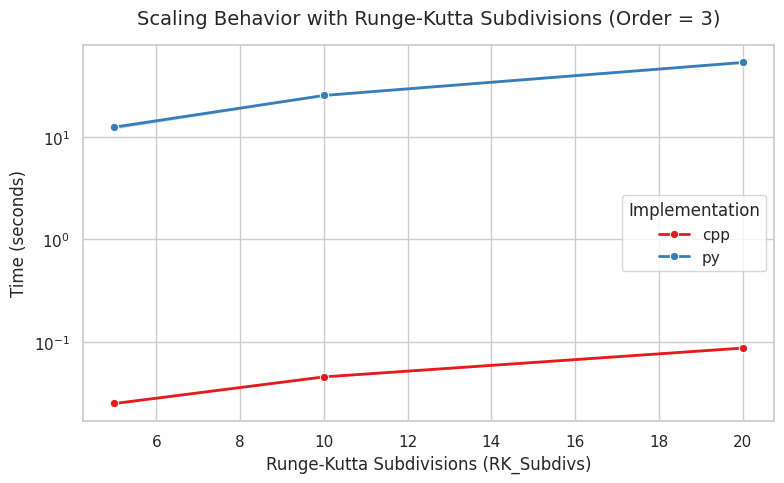

In [ ]:
df_list = []
for key, runtime in timings.items():
    impl, order, rk_subdvs, int_subdvs = key
    df_list.append({
        "Implementation": impl,
        "Order": order,
        "RK_Subdivs": rk_subdvs,
        "Int_Subdivs": int_subdvs,
        "Time_Sec": runtime
    })
df = pd.DataFrame(df_list)
df.to_csv("outputs/performance_data.csv", index=False)

sns.set_theme(style="whitegrid")

# Mean Execution Time vs. Order
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x="Order", y="Time_Sec", hue="Implementation", ax=ax, palette="Set2")
ax.set_yscale("log")  # Using log scale to handle the wide performance gap
ax.set_title("Mean Execution Time Comparison by Order (Log Scale)", fontsize=14, pad=15)
ax.set_xlabel("Order", fontsize=12)
ax.set_ylabel("Time (seconds)", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/perf_by_order.png", dpi=150)
plt.show()
plt.close()

# Scaling across Runge-Kutta Subdivisions
df_order3 = df[df["Order"] == 6]

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_order3, x="RK_Subdivs", y="Time_Sec", hue="Implementation", marker="o", ax=ax, palette="Set1", linewidth=2)
ax.set_yscale("log")
ax.set_title("Scaling Behavior with Runge-Kutta Subdivisions (Order = 3)", fontsize=14, pad=15)
ax.set_xlabel("Runge-Kutta Subdivisions (RK_Subdivs)", fontsize=12)
ax.set_ylabel("Time (seconds)", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/perf_scaling_rk.png", dpi=150)
plt.show()
plt.close()

In [71]:
# 1. Pivot table to compare performance side by side
df_pivot = df.pivot(
    index=["Order", "RK_Subdivs", "Int_Subdivs"], 
    columns="Implementation", 
    values="Time_Sec"
).reset_index()

# 2. speedup
df_pivot["Speedup"] = df_pivot["py"] / df_pivot["cpp"]

# 3. stats
average_speedup = df_pivot["Speedup"].mean()
median_speedup = df_pivot["Speedup"].median()
min_speedup = df_pivot["Speedup"].min()
max_speedup = df_pivot["Speedup"].max()

print(f"Average Speedup: {average_speedup:.2f}x faster")
print(f"Median Speedup:  {median_speedup:.2f}x faster")
print(f"Minimum Speedup: {min_speedup:.2f}x faster")
print(f"Maximum Speedup: {max_speedup:.2f}x faster")

Average Speedup: 545.03x faster
Median Speedup:  547.12x faster
Minimum Speedup: 482.68x faster
Maximum Speedup: 610.12x faster
